# Análisis Dataset
En este notebook analizaremos el dataset OPUS-100

In [2]:
#Descargamos el dataset
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("opus100", "en-es")
dataset #Vemos estructura datos

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})

Trabajaremos con pandas para facilitar las correspondientes modificaciones

In [3]:
import pandas as pd

train = pd.DataFrame(dataset['train']['translation'])
val = pd.DataFrame(dataset['validation']['translation'])
test = pd.DataFrame(dataset['test']['translation'])

train.head()

,en,es
0,"It was the asbestos in here, that's what did it!",Fueron los asbestos aquí. ¡Eso es lo que ocurrió!
1,I'm out of here.,Me voy de aquí.
2,"One time, I swear I pooped out a stick of chalk.","Una vez, juro que cagué una barra de tiza."
3,"And I will move, do you understand me?","Y prefiero mudarme, ¿Entiendes?"
4,"- Thank you, my lord.",- Gracias.


In [4]:
# Así medimos la longitud de la partición completa, sin entrar a la columna
print(f"Tamaño dataset inicial Train: {len(dataset['train'])}")
print(f"Tamaño dataset inicial Test: {len(dataset['test'])}")
print(f"Tamaño dataset inicial Validation: {len(dataset['validation'])}")

Tamaño dataset inicial Train: 1000000
Tamaño dataset inicial Test: 2000
Tamaño dataset inicial Validation: 2000


## Filtrado de datos
Como en todo dataset, es necesario filtar y eliminar "basura":

- Datos nulos
- Frases o cadenas vacías
- Frases con menos de 3 palabras
- Eliminar pares de frases duplicadas
- Eliminar aquellas frases donde la traducción del español tenga el doble de palabras o menos de la mitad (ratio)

In [5]:
#Nulos y duplicados
train_clean = train.dropna().copy()
train_clean = train_clean.drop_duplicates(subset=['en','es'])


#Texto sin espacios y en minuscula
en_text = train_clean['en'].str.lower().str.strip() 
es_text = train_clean['es'].str.lower().str.strip()

#Longitudes de las frases
long_en = train_clean['en'].str.split().str.len()
long_es = train_clean['es'].str.split().str.len()
ratio = long_es / long_en

#Mascaras
not_empy = (en_text != "") & (es_text != "")
not_equal = (en_text != es_text)
ming_lon = (long_en >= 3) & (long_es >= 3)
m_ratio = (ratio > 0.5) & (ratio < 2.0)


#Filtro
mask = not_empy & not_equal & ming_lon & m_ratio
train_clean = train_clean[mask]


print(f"Pares de frases eliminados: {len(train) - len(train_clean)}")

Pares de frases eliminados: 240144


## Estructura de los datos

Una vez eliminados los datos redundantes estudiamos que estructura o forma tienen los datos de entrenamiento.


Calcularemos las longitudes y definiremos el ratio como la longitud de la frase en español dividido por la longitud de la frase en ingles.

Tambien calcularemos percentelis

In [6]:
metrics = pd.DataFrame()

metrics['long_en'] = train_clean['en'].str.split().str.len()
metrics['long_es'] = train_clean['es'].str.split().str.len()
metrics['ratio'] = metrics['long_es'] / metrics['long_en']


pd.options.display.float_format = '{:.2f}'.format
metrics.head()



,long_en,long_es,ratio
0,10,9,0.90
1,4,4,1.00
2,11,9,0.82
7,14,15,1.07
8,6,7,1.17


In [7]:
percentiles = [.25, .5, .75, .9, .95]
datos = metrics[[ 'long_en', 'long_es','ratio']].describe(percentiles=percentiles)

datos

,long_en,long_es,ratio
count,759856.00,759856.00,759856.00
mean,12.94,13.46,1.02
std,13.21,14.84,0.24
min,3.00,3.00,0.50
25%,5.00,5.00,0.83
50%,8.00,8.00,1.00
75%,16.00,16.00,1.17
90%,28.00,31.00,1.33
95%,38.00,43.00,1.45
max,1737.00,1721.00,1.98


Observamos que, a pesar de que el 95% de las frases tengan una longitud menor o igual a 38 en ingles, la lonngitud maxima es de 1737 por lo que aun asi decidimos filtrar más las traducciones en base 
a esta observacion:

In [8]:
long_en = train_clean['en'].str.split().str.len()
long_es = train_clean['es'].str.split().str.len()

train_clean = train_clean[(long_en <= 64) & (long_es <= 64)]

print(f"Tamaño final del dataset: {len(train_clean)}")

Tamaño final del dataset: 749103


También calcularemos el vocabulario o diccionario de palabras que contiene el conjunto de entrenamiento, es decir, el número de palabras distintas que tiene

In [9]:
def diccionario(df):

    #aplica a cada frase una separacion por caracteres sin tener en cuenta signos de puntuacion, interrogacion y exclamacion
    #\w+ es una ER
    vocab = df.str.lower().str.findall(r'\w+') ##tipo panda.Series()
    vocab = vocab.explode() #convierte cada elemento en una fila pero no tiene en cuenta repetidos
    vocab = vocab.value_counts()
    
    return vocab.to_dict()


en_vocab = diccionario(train_clean['en'])
es_vocab = diccionario(train_clean['es'])

vocab = pd.DataFrame()
vocab['Palabras Unicas Ingles'] = [len(en_vocab)]
vocab['Palabras Unicas Español'] = [len(es_vocab)]
vocab
    

,Palabras Unicas Ingles,Palabras Unicas Español
0,152068,208369


Una vez tenemos el diccionario queremos que palabrás se repiten más veces

In [10]:
from collections import Counter
import re

n = 10

top_en = Counter(en_vocab).most_common(n)
top_es = Counter(es_vocab).most_common(n)
    
# Creamos el DataFrame
tabla = pd.DataFrame({
    'Rank': range(1, n + 1),
    'Word (EN)': [word for word, count in top_en],
    'Freq (EN)': [f"{count:,}" for word, count in top_en],
    'Word (ES)': [word for word, count in top_es],
    'Freq (ES)': [f"{count:,}" for word, count in top_es]
    })

tabla

,Rank,Word (EN),Freq (EN),Word (ES),Freq (ES)
0,1,the,"532,625",de,"582,017"
1,2,of,"268,586",la,"331,605"
2,3,to,"249,572",que,"266,058"
3,4,and,"222,554",el,"237,683"
4,5,you,"182,139",en,"230,591"
5,6,i,"179,156",y,"218,430"
6,7,a,"174,868",a,"205,047"
7,8,in,"165,885",los,"142,553"
8,9,that,"114,410",no,"140,768"
9,10,it,"104,917",un,"101,677"


Por último es interesante ver como se distribuyen los datos mediante un histograma

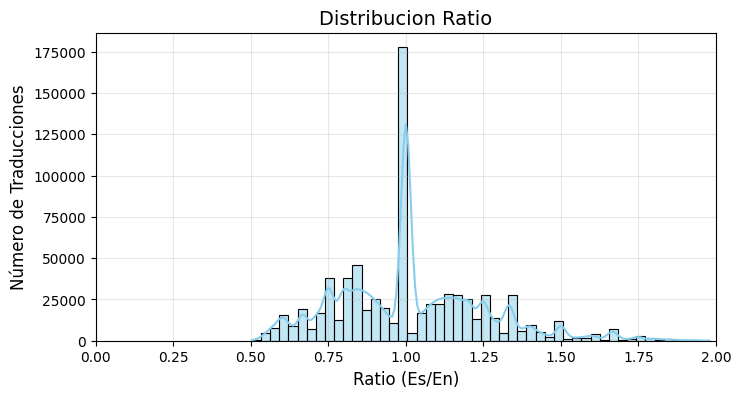

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from config import MEDIA_PATH
import os

def histograma(df,title,x_label,y_label,x_min,x_max,save_fig="histograma",bins = 50,color = 'skyblue'):
    plt.figure(figsize=(8, 4))
    
    # Creamos el histograma con una línea de densidad (KDE)
    sns.histplot(df, bins=bins, kde=True, color=color)
    
   
    # Configuración de estética
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.xlim(x_min, x_max) # Limitamos la vista para que se vea bien el grueso de los datos
    plt.grid(alpha=0.3)
    
    plt.savefig(save_fig)
    plt.show()


# Para ejecutarlo:
histograma(metrics['ratio'],title="Distribucion Ratio",x_label="Ratio (Es/En)",y_label="Número de Traducciones",x_min = 0,x_max=2, save_fig= os.path.join(MEDIA_PATH,"histograma_ratio"))

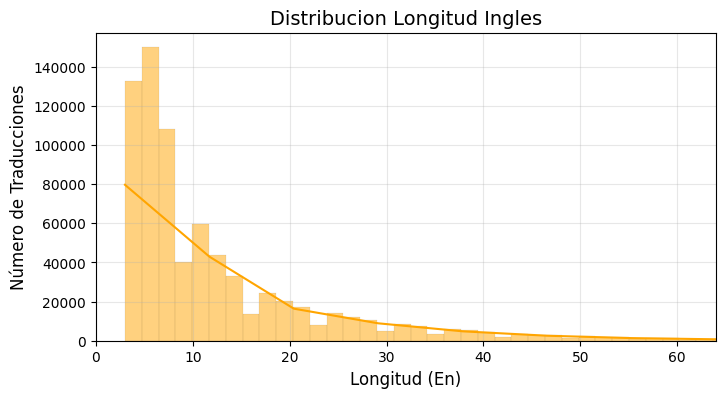

In [15]:
histograma(metrics['long_en'],title="Distribucion Longitud Ingles",x_label="Longitud (En)",y_label="Número de Traducciones",x_min=0,x_max=64,bins = 1000,color="orange",save_fig= os.path.join(MEDIA_PATH,"histograma_lon_en"))

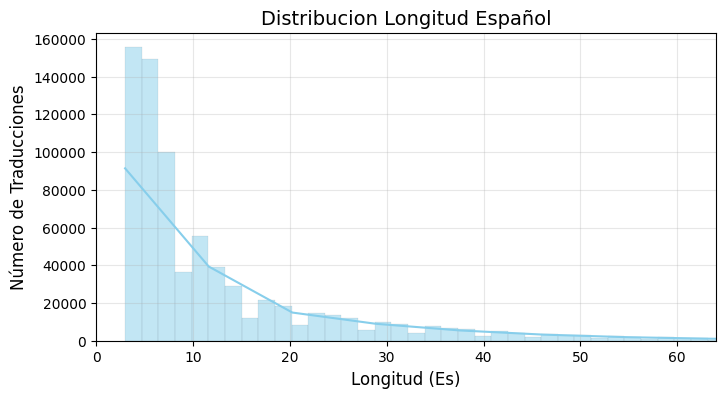

In [16]:
histograma(metrics['long_es'],title="Distribucion Longitud Español",x_label="Longitud (Es)",y_label="Número de Traducciones",x_min=0,x_max=64,bins = 1000,color="skyblue",save_fig= os.path.join(MEDIA_PATH,"histograma_lon_es"))